In [1]:
# --- IMPORT STATEMENTS ---
import numpy as np
import healpy as hp

import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS



In [2]:
# --- GLOBAL VARIABLES ---

# LINUX_DIRECTORY = "/home/aimee/mphys"
LINUX_DIRECTORY = "/home/u20482jg/MPHYS_Project_Local/"
# EFFLESBERG_DIR = f'{LINUX_DIRECTORY}/data/maps' # Aimee
EFFLESBERG_DIR = f'{LINUX_DIRECTORY}/data/all_maps/maps' # Joe
# FIGURE_SAVEDIR = "figures" # Aimee
FIGURE_SAVEDIR = "figures/masking" # Joe
SAVE_FIGS = False

# Get precise values! these were eyeballed
L_BOUNDS = [0, 65] # degrees
B_BOUNDS = [-5, 5] # degrees

EFFELSBERG_MAPS = {
    "Effelsberg 1.43 GHz (10')":"EFFELSBERG-1.4285714285714286GHz-10.0amin.fits",
    "Effelsberg 1.43 GHz (15')":"EFFELSBERG-1.4285714285714286GHz-15.0amin.fits",
    "Effelsberg 1.43 GHz (20')":"EFFELSBERG-1.4285714285714286GHz-20.0amin.fits",
    "Effelsberg 1.43 GHz (25')":"EFFELSBERG-1.4285714285714286GHz-25.0amin.fits",
    "Effelsberg 1.43 GHz (30')":"EFFELSBERG-1.4285714285714286GHz-30.0amin.fits",
    "Effelsberg 1.43 GHz (60')":"EFFELSBERG-1.4285714285714286GHz-60.0amin.fits",
    "Effelsberg 2.73 GHz (5')":"EFFELSBERG-2.7272727272727275GHz-5.0amin.fits",
    "Effelsberg 2.73 GHz (10')":"EFFELSBERG-2.7272727272727275GHz-10.0amin.fits",
    "Effelsberg 2.73 GHz (15')":"EFFELSBERG-2.7272727272727275GHz-15.0amin.fits",
    "Effelsberg 2.73 GHz (20')":"EFFELSBERG-2.7272727272727275GHz-20.0amin.fits",
    "Effelsberg 2.73 GHz (25')":"EFFELSBERG-2.7272727272727275GHz-25.0amin.fits",
    "Effelsberg 2.73 GHz (30')":"EFFELSBERG-2.7272727272727275GHz-30.0amin.fits",
    "Effelsberg 2.73 GHz (60')":"EFFELSBERG-2.7272727272727275GHz-60.0amin.fits"
}
EFFELSBERG_KEYS = list(EFFELSBERG_MAPS.keys())
# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index

In [3]:
# --- FUNCTION DEFINITIONS ----

In [4]:
def get_map(path, l_bounds=None, b_bounds=None, noise_index=3): # from maps_processing.ipynb
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    # DEBUG
    for i, hdu in enumerate(fits_file):
        print(f"HDU {i} header:")
        print(hdu.header)
    # /DEBUG 

    data = fits_file[0].data * 1000 # convert to mK

    try: # debug for no noise layer
        noise = 1/fits_file[noise_index].data * 1000 # convert to mK
    except IndexError:
        noise = None

    header = fits_file[0].header
    wcs = WCS(header)

    if l_bounds and b_bounds is not None:
        upper_l, lower_b = wcs.all_world2pix(l_bounds[0], b_bounds[0], 0)
        lower_l, upper_b = wcs.all_world2pix(l_bounds[1], b_bounds[1], 0)

        cutout = data[int(lower_b):int(upper_b)+1,
                      int(lower_l):int(upper_l)+1].copy()
        
        if noise:  # debug for no noise layer
            cutout_noise = noise[int(lower_b):int(upper_b)+1,
                                int(lower_l):int(upper_l)+1].copy()
        else:
            cutout_noise = None

        cutout[cutout==np.nan] = 0

        new_header = fits.Header()
        new_header['CTYPE1'] = wcs.wcs.ctype[0]
        new_header['CTYPE2'] = wcs.wcs.ctype[1]
        new_header['CRVAL1'] = l_bounds[1]
        new_header['CRVAL2'] = b_bounds[0]
        new_header['CRPIX1'] = 1
        new_header['CRPIX2'] = 1
        new_header['PC1_1'] = 1.0
        new_header['PC1_2'] = 0.0
        new_header['PC2_1'] = 0.0
        new_header['PC2_2'] = 1.0
        new_header['CDELT1'] = header['CDELT1']
        new_header['CDELT2'] = header['CDELT2']
        new_header['NAXIS1'] = upper_l - lower_l
        new_header['NAXIS2'] = upper_b - lower_b
        new_wcs = WCS(new_header)
        print(f"Cutout WCS:\n {new_wcs}")

        return cutout, cutout_noise, new_header, new_wcs
    
    else:
        print("Raw WCS:\n {wcs}")
        
        return data, noise, header, wcs

In [5]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = -0.01 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if SAVE_FIGS:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [6]:
def split_diameter(diameter_str):
    
    try: # x and y the same (circle)
        diameter = (float(diameter_str), float(diameter_str))
    except ValueError: # x and y different (ellipse) - separated by 'x'
        temp = diameter_str.split('x')
        diameter = (float(temp[0]), float(temp[1]))

    return diameter

In [7]:
def read_snr_catalogue_simple(file_path, include_uncertain=True):
    # From D. A. Green SNR Catalogue: https://www.mrao.cam.ac.uk/surveys/snrs/snrs.data.html

    x_coords = [] # galactic coords - l
    y_coords = [] # galactic coords - b
    diameters = [] # arcmin (diameter, not radius - see documentation on website)

    with open(file_path, 'r') as file:
        for i, line in enumerate(file):
            if i > 2: # skip headers
                valid = True
                arr = line.split()
            
                x_coord = float(arr[0])

                y_coord = float(arr[1])
                
                diameter_str = arr[7] 
                if '?' in diameter_str: 
                    if include_uncertain:
                        diameter = split_diameter(diameter_str.replace('?', '')) 
                    else:
                        # print(f'Line {i} contains uncertain diameter - skipping line')
                        valid = False
                else:
                    diameter = split_diameter(diameter_str)
        
                if valid:
                    x_coords.append(x_coord)
                    y_coords.append(y_coord)
                    diameters.append(diameter)
    
    return x_coords, y_coords, diameters

In [8]:
def read_snr_catalogue(file_path, include_uncertain=True):
    # From D. A. Green SNR Catalogue: https://www.mrao.cam.ac.uk/surveys/snrs/snrs.data.html

    x_coords = [] # galactic coords - l
    y_coords = [] # galactic coords - b
    diameters = [] # arcmin (diameter, not radius - see documentation on website)
    fluxes_1GHz = [] # Jy
    spectral_indices = []

    with open(file_path, 'r') as file:
        for i, line in enumerate(file):
            if i > 2: # skip headers
                valid = True
                arr = line.split()
            
                x_coord = float(arr[0])

                y_coord = float(arr[1])
                
                diameter_str = arr[7] 
                if '?' in diameter_str: 
                    if include_uncertain:
                        diameter = split_diameter(diameter_str.replace('?', '')) 
                    else:
                        # print(f'Line {i} contains uncertain diameter - skipping line')
                        valid = False
                else:
                    diameter = split_diameter(diameter_str)
                
                flux_1GHz_str = arr[9]
                if flux_1GHz_str == '?':
                    # print(f'Line {i} contains no flux - skipping line')
                    valid = False
                elif ('<' in flux_1GHz_str) or ('>' in flux_1GHz_str): # I hate this catalogue so much
                    # print(f'Line {i} contains flux with inequality - skipping line')
                    valid = False
                elif '?' in flux_1GHz_str:
                    if include_uncertain:
                        flux_1GHz = float(flux_1GHz_str.replace('?', ''))
                    else:
                        # print(f'Line {i} contains uncertain flux - skipping line')
                        valid = False
                else:
                    flux_1GHz = float(flux_1GHz_str)

                spectral_index_str = arr[10]
                if (spectral_index_str == '?') or (spectral_index_str == 'varies'):
                    # print(f'Line {i} contains no/varying spectral index - skipping line')
                    valid = False
                elif '?' in spectral_index_str:
                    if include_uncertain:
                        spectral_index = float(spectral_index_str.replace('?', ''))
                    else:
                        # print(f'Line {i} contains uncertain spectral index - skipping line')
                        valid = False
                else:
                    spectral_index = float(spectral_index_str)
                
                if valid:
                    x_coords.append(x_coord)
                    y_coords.append(y_coord)
                    diameters.append(diameter)
                    fluxes_1GHz.append(flux_1GHz)
                    spectral_indices.append(spectral_index)


    return x_coords, y_coords, diameters, fluxes_1GHz, spectral_indices


In [9]:
def convert_flux(flux_1, spectral_index, frequency_1, frequency_2):

    flux_2 = flux_1 * (frequency_2 / frequency_1)**spectral_index

    return flux_2

In [10]:
def convert_snr_coords(x_coords, y_coords, WCS):

    x_min, y_min = WCS.all_world2pix(float(L_BOUNDS[0]), float(B_BOUNDS[0]), 0)
    x_max, y_max = WCS.all_world2pix(float(L_BOUNDS[1]), float(B_BOUNDS[1]), 0)

    x_coords_new = []
    y_coords_new = []
    for i, _ in enumerate(x_coords):
        l = x_coords[i] 
        b = y_coords[i]
        x, y = WCS.all_world2pix(float(l), float(b), 0)

        # only append if in range
        if (x < x_min) & (x > x_max) & (y > y_min) & (y < y_max): # x inequalities flipped because axis reversed
            x_coords_new.append(x)
            y_coords_new.append(y)
    
    return x_coords_new, y_coords_new

In [11]:
def main():
    
    # Read and plot Efflesberg
    map_name = EFFELSBERG_MAPS["Effelsberg 2.73 GHz (5')"]
    map_path = f'{EFFLESBERG_DIR}/{map_name}'
    data, noise, header, wcs = get_map(map_path, l_bounds=L_BOUNDS, b_bounds=B_BOUNDS)
    plot_fits(data, wcs, title="Effelsberg 2.73 GHz (5')")

    # FIRST STEP - Eyeballing
    
    l_snr, b_snr, diameters = read_snr_catalogue_simple(file_path=f'{LINUX_DIRECTORY}/data/SNR_Catalogue_DAGreen.txt', include_uncertain=True)

    # Cut SNR list to GDIGS l and b range
    diameter_l = [d[0] for d in diameters]
    diameter_b = [d[1] for d in diameters]
    data_arr = np.array([l_snr, b_snr, diameter_l, diameter_b]).T
    temp = []
    for row in data_arr:
        l = row[0]
        b = row[1]
        if (l < L_BOUNDS[1]) & (l > L_BOUNDS[0]) & (b > B_BOUNDS[0]) & (b < B_BOUNDS[1]): # x inequalities flipped because axis reversed
            temp.append(row)
    data_arr = np.array(temp)
    
    # Plot on map and print info
    
    print(f'{len(data_arr)} SNR found in range.')
    print('Coordinates (l, b) [degrees], diameters (l, b) [arcmin]')
    for i, line in enumerate(data_arr):
        print(f'SNR {i+1}: ({line[0]}, {line[1]}), ({line[2]}, {line[3]})')
    
    x_snr, y_snr = convert_snr_coords(l_snr, b_snr, wcs)
    plot_fits(data, wcs, x_coords=x_snr, y_coords=y_snr, title="Effelsberg 2.73 GHz (5') - SNR Locations") 

    # SECOND STEP - Flux threshold

    # Exclude SNRs with fluxes (at 30GHz) < GDIGS background flux
    l_snr, b_snr, diameters, fluxes_1GHz, spectral_indices = read_snr_catalogue(file_path=f'{LINUX_DIRECTORY}/data/SNR_Catalogue_DAGreen.txt', include_uncertain=True)
    
    # Cut SNR list to GDIGS l and b range
    diameter_l = [d[0] for d in diameters]
    diameter_b = [d[1] for d in diameters]
    data_arr = np.array([l_snr, b_snr, diameter_l, diameter_b, fluxes_1GHz, spectral_indices]).T
    temp = []
    for row in data_arr:
        l = row[0]
        b = row[1]
        if (l < L_BOUNDS[1]) & (l > L_BOUNDS[0]) & (b > B_BOUNDS[0]) & (b < B_BOUNDS[1]): # x inequalities flipped because axis reversed
            temp.append(row)
    data_arr = np.array(temp)

    # Filter out values with low flux (dummy function for now)
    temp = []
    for row in data_arr:
        flux_1GHz = row[4]
        spectral_index = row[5]
        flux_30GHz = convert_flux(flux_1GHz, spectral_index, 1e9, 30e9)
        if flux_30GHz > 0: # temp - change to bg later
            temp.append(row)
    data_arr_cut = np.array(temp)

    # Plot on map and print info
    
    print(f'{len(data_arr_cut)} SNR with valid frequency/spectral index found in range.')
    print('Coordinates (l, b) [degrees], diameters (l, b) [arcmin], flux @ 30 GHz [Jy], spectral index')
    for i, line in enumerate(data_arr_cut):
        print(f'SNR {i+1}: ({line[0]}, {line[1]}), ({line[2]}, {line[3]}), {line[4]}, {line[5]}')

    x_snr, y_snr = convert_snr_coords(data_arr[:,0], data_arr[:,1], wcs)
    plot_fits(data, wcs, x_coords=x_snr, y_coords=y_snr, title="Effelsberg 2.73 GHz (5') - SNR Locations (valid flux/spectral index)") 



Getting data from /home/u20482jg/MPHYS_Project_Local//data/all_maps/maps/EFFELSBERG-2.7272727272727275GHz-5.0amin.fits
HDU 0 header:
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 3999                                                  NAXIS2  =                  799                                                  WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =               2000.0 / Pixel coordinate of reference point            CRPIX2  =                400.0 / Pixel coordinate of reference point            CDELT1  =   -0.016666666666667 / [deg] Coordinate increment at reference point  CDELT2  =    0.016666666666667 / [deg] Coordinate increment at reference point  CUNIT1  = 'deg'                / Units of coordinate increment and 

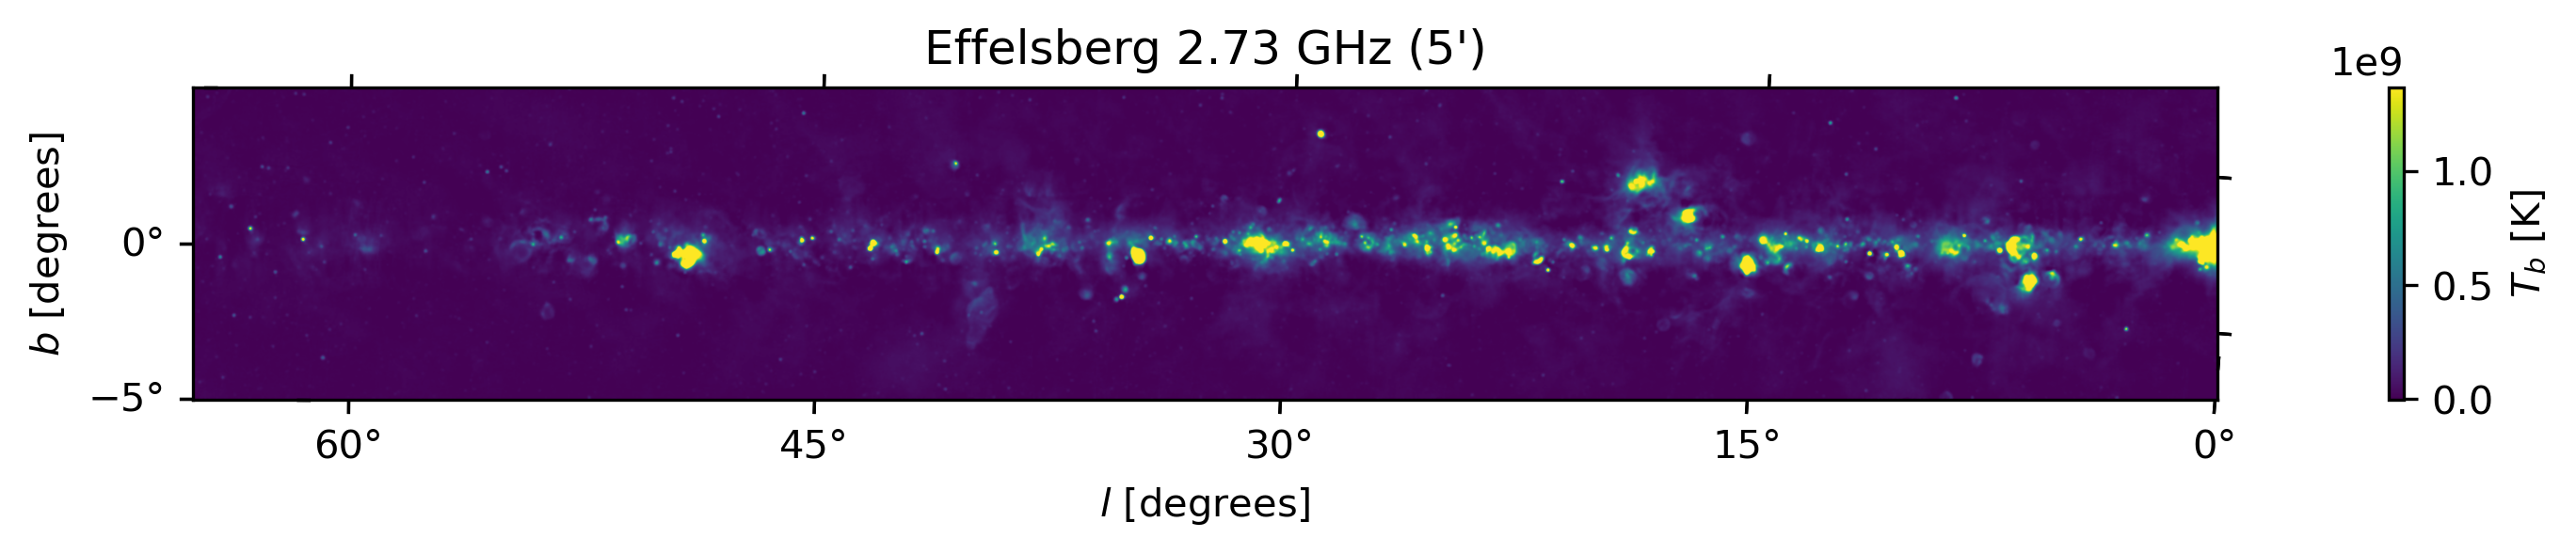

115 SNR found in range.
Coordinates (l, b) [degrees], diameters (l, b) [arcmin]
SNR 1: (0.3, 0.0), (15.0, 8.0)
SNR 2: (0.9, 0.1), (8.0, 8.0)
SNR 3: (1.0, -0.1), (8.0, 8.0)
SNR 4: (1.4, -0.1), (10.0, 10.0)
SNR 5: (1.9, 0.3), (1.5, 1.5)
SNR 6: (3.1, -0.6), (52.0, 28.0)
SNR 7: (3.7, -0.2), (14.0, 11.0)
SNR 8: (3.8, 0.3), (18.0, 18.0)
SNR 9: (4.2, -3.5), (28.0, 28.0)
SNR 10: (5.2, -2.6), (18.0, 18.0)
SNR 11: (5.4, -1.2), (35.0, 35.0)
SNR 12: (5.5, 0.3), (15.0, 12.0)
SNR 13: (5.9, 3.1), (20.0, 20.0)
SNR 14: (6.1, 0.5), (18.0, 12.0)
SNR 15: (6.1, 1.2), (30.0, 26.0)
SNR 16: (6.4, -0.1), (48.0, 48.0)
SNR 17: (6.4, 4.0), (31.0, 31.0)
SNR 18: (6.5, -0.4), (18.0, 18.0)
SNR 19: (7.0, -0.1), (15.0, 15.0)
SNR 20: (7.2, 0.2), (12.0, 12.0)
SNR 21: (7.5, -1.7), (100.0, 100.0)
SNR 22: (7.7, -3.7), (22.0, 22.0)
SNR 23: (8.7, -0.1), (45.0, 45.0)
SNR 24: (8.9, 0.4), (24.0, 24.0)
SNR 25: (9.7, -0.0), (15.0, 11.0)
SNR 26: (9.8, 0.6), (12.0, 12.0)
SNR 27: (9.9, -0.8), (12.0, 12.0)
SNR 28: (11.0, -0.0), (11.0,

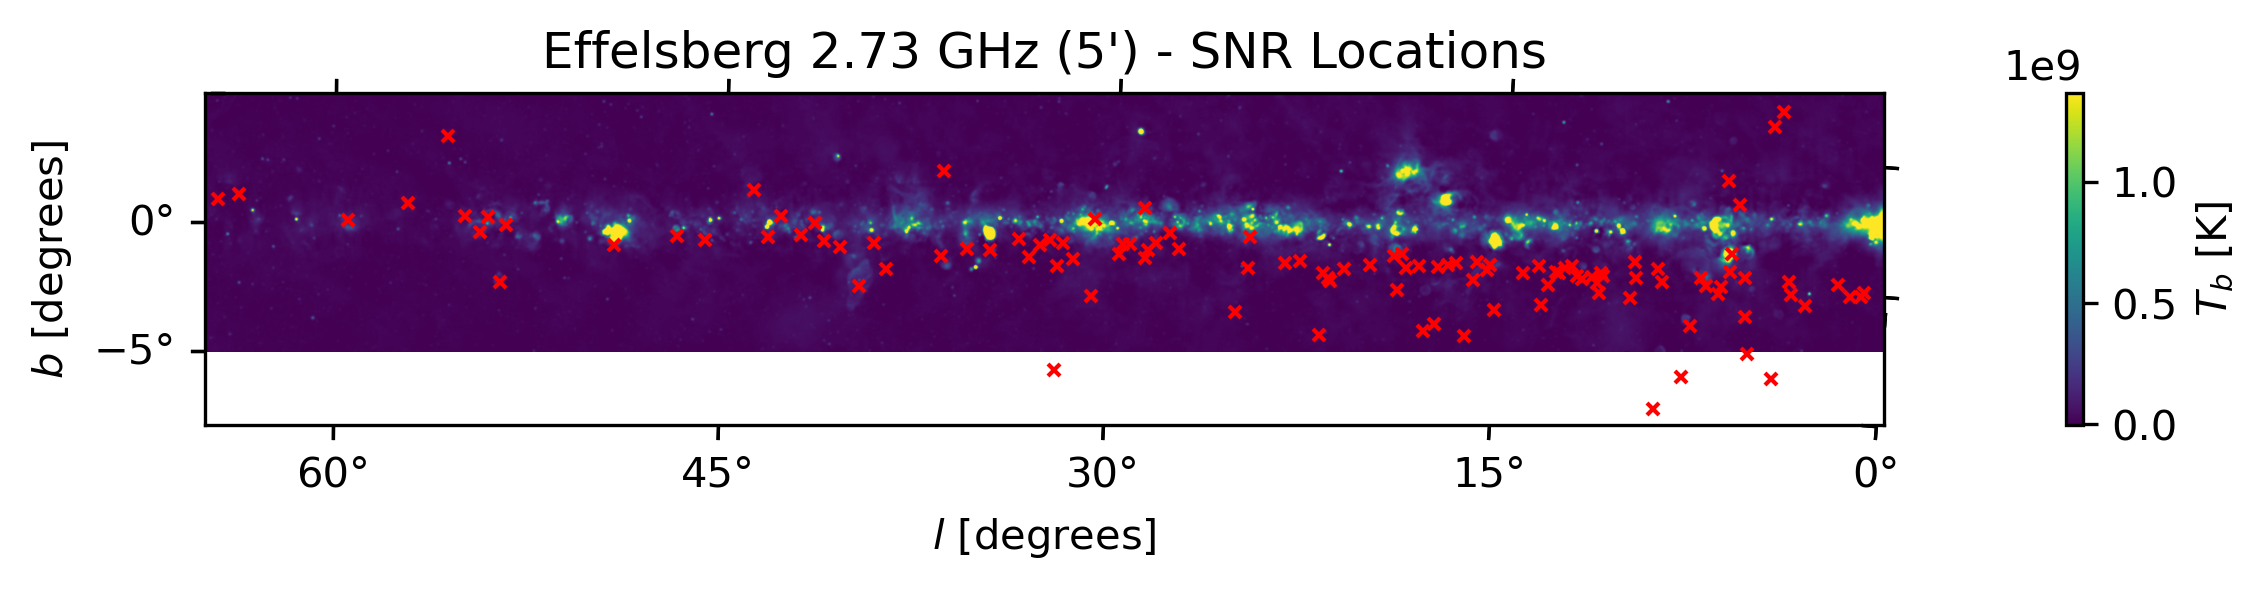

99 SNR with valid frequency/spectral index found in range.
Coordinates (l, b) [degrees], diameters (l, b) [arcmin], flux @ 30 GHz [Jy], spectral index
SNR 1: (0.3, 0.0), (15.0, 8.0), 22.0, 0.6
SNR 2: (1.0, -0.1), (8.0, 8.0), 15.0, 0.6
SNR 3: (1.9, 0.3), (1.5, 1.5), 0.6, 0.6
SNR 4: (3.1, -0.6), (52.0, 28.0), 5.0, 0.9
SNR 5: (3.7, -0.2), (14.0, 11.0), 2.3, 0.65
SNR 6: (3.8, 0.3), (18.0, 18.0), 3.0, 0.6
SNR 7: (4.2, -3.5), (28.0, 28.0), 3.2, 0.6
SNR 8: (5.2, -2.6), (18.0, 18.0), 2.6, 0.6
SNR 9: (5.4, -1.2), (35.0, 35.0), 35.0, 0.2
SNR 10: (5.5, 0.3), (15.0, 12.0), 5.5, 0.7
SNR 11: (5.9, 3.1), (20.0, 20.0), 3.3, 0.4
SNR 12: (6.1, 0.5), (18.0, 12.0), 4.5, 0.9
SNR 13: (6.1, 1.2), (30.0, 26.0), 4.0, 0.3
SNR 14: (6.4, 4.0), (31.0, 31.0), 1.3, 0.4
SNR 15: (6.5, -0.4), (18.0, 18.0), 27.0, 0.6
SNR 16: (7.0, -0.1), (15.0, 15.0), 2.5, 0.5
SNR 17: (7.2, 0.2), (12.0, 12.0), 2.8, 0.6
SNR 18: (7.5, -1.7), (100.0, 100.0), 18.0, 0.7
SNR 19: (7.7, -3.7), (22.0, 22.0), 11.0, 0.32
SNR 20: (8.7, -0.1), (45.0

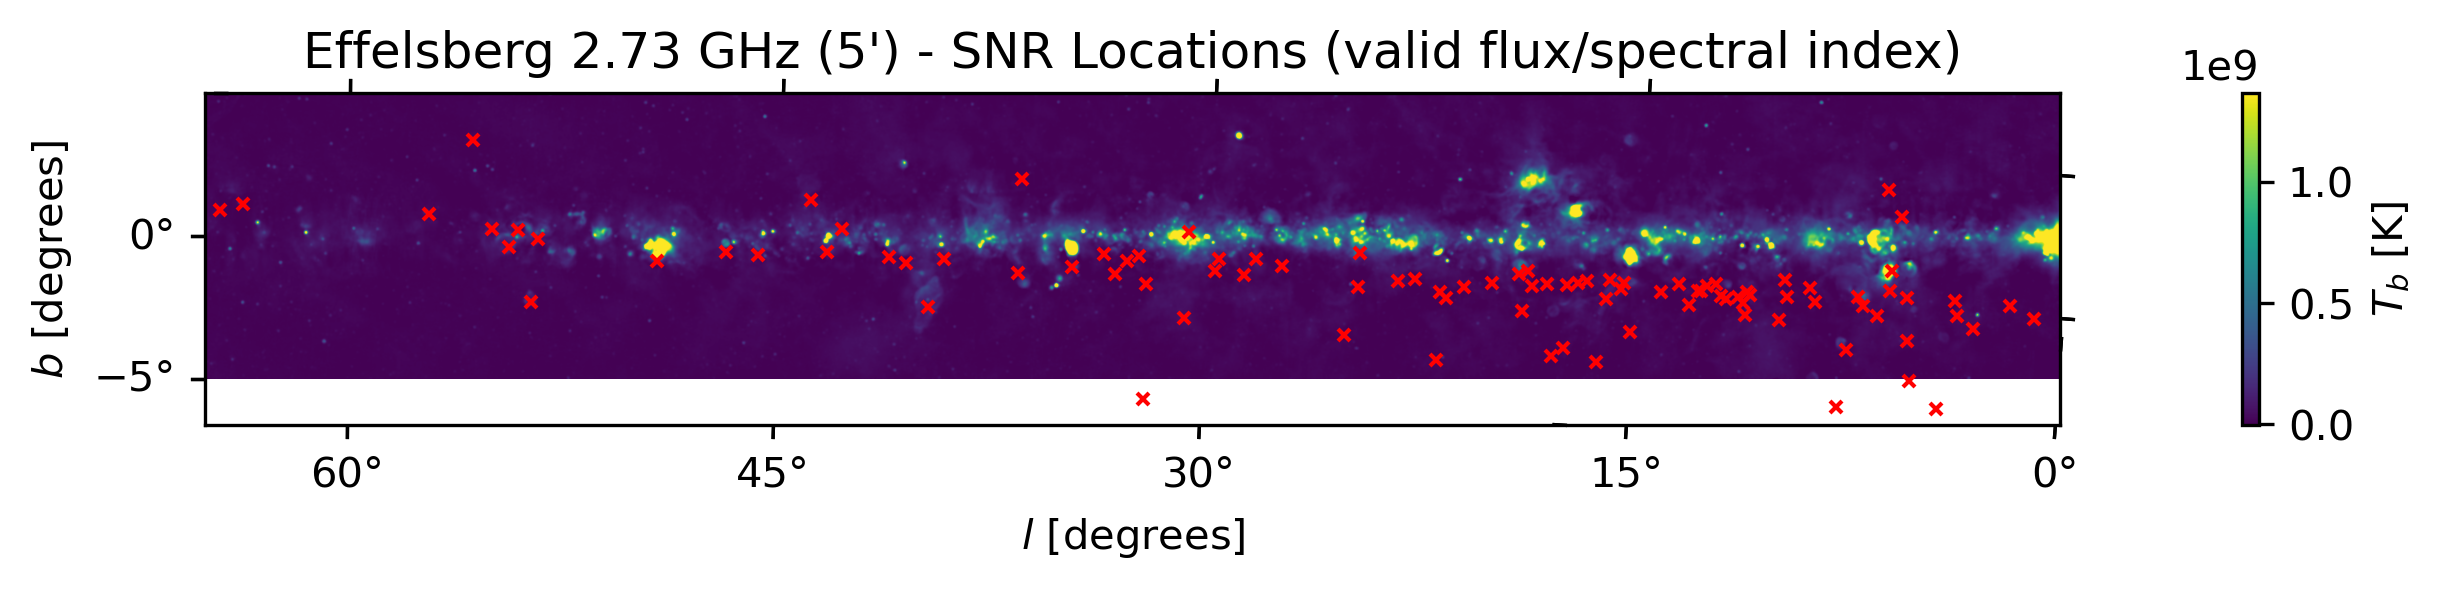

In [12]:
main() # see Thursday week 5 for how I made the final list - saved as SNRs_final.csv